# Example: automated graph calculation code generation using Paragraphulator
*J. Aumentado, 04-22-26*


## Introduction
You can use **Paragraphulator** to generate Python code that computes the scattering parameters of a given graph. Assuming you already know how to populate the physical parameters for a graph, Paragraphulator can generate python code that sets up the graph scattering calculation for you. While the app does a fine job of showing you the calculated scattering parameters, it's often useful to extend the code to plot the dependence on other parameters (coupling, dissipation rates, detuning, etc.), or as part of some larger, more complicated calculation.

## Example: 2-mode parametric amplification
Set up a 2-mode amplifier graph as shown below:

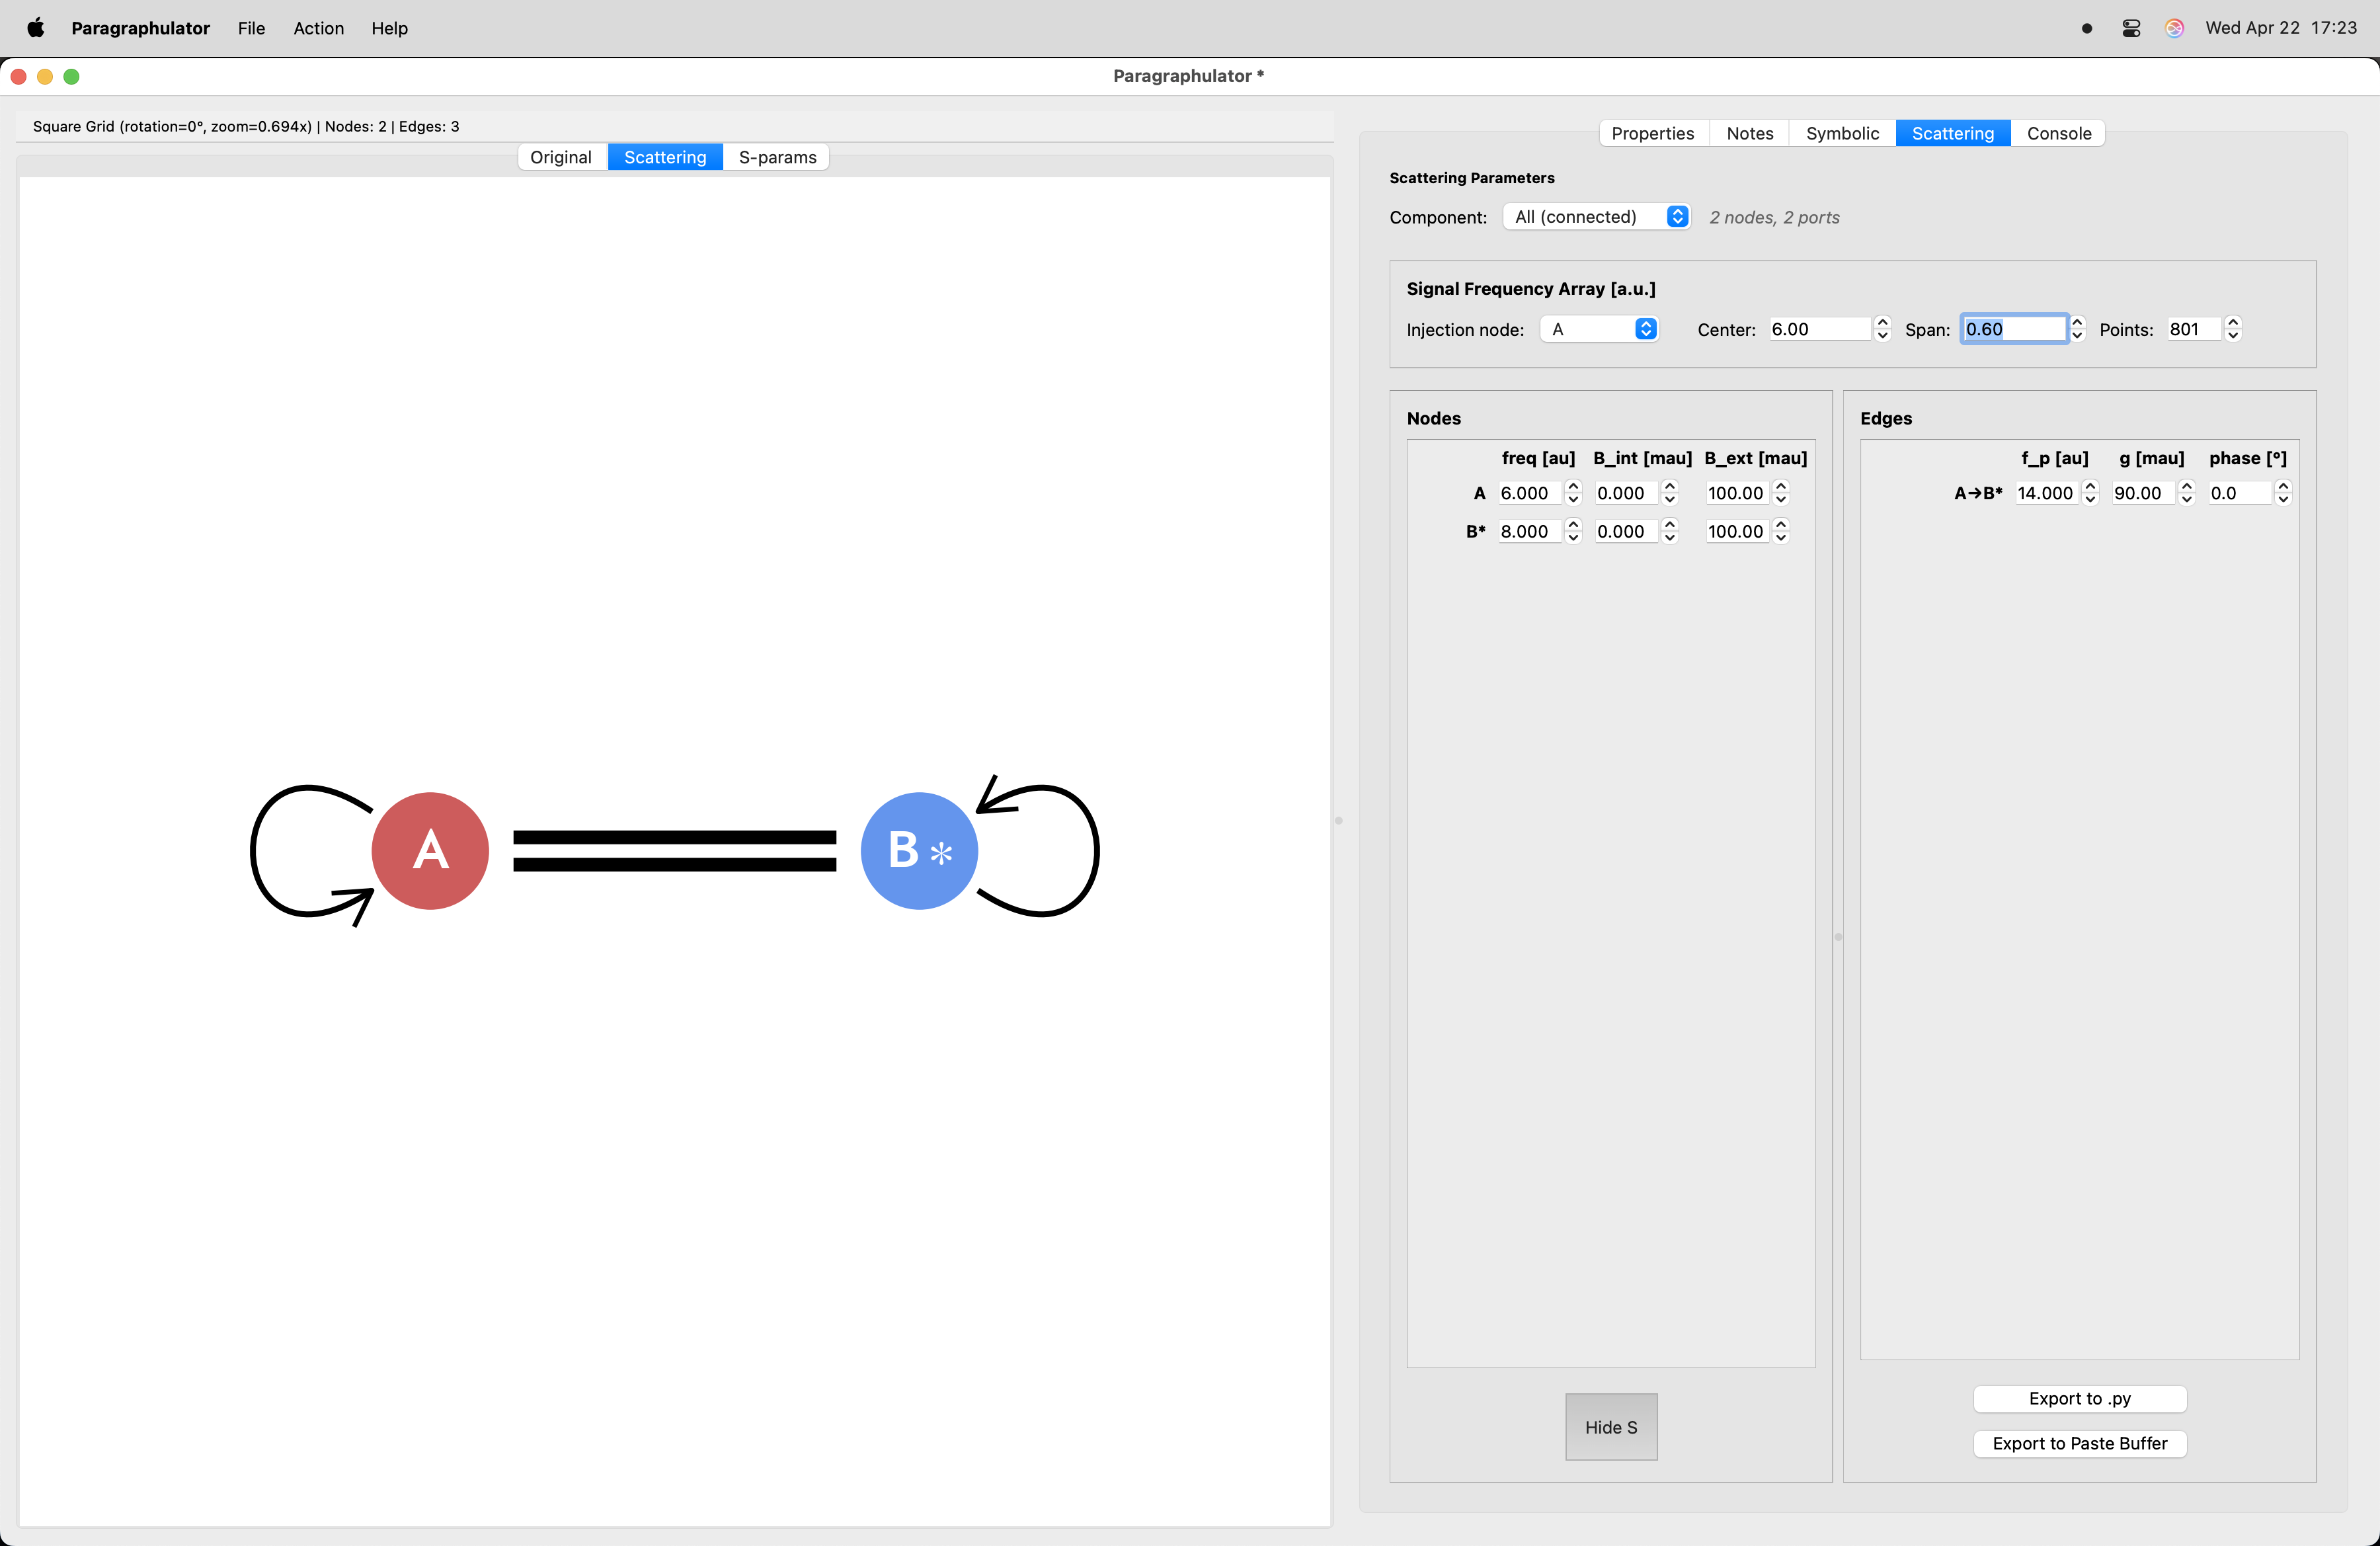

... which should give you the scattering parameters,
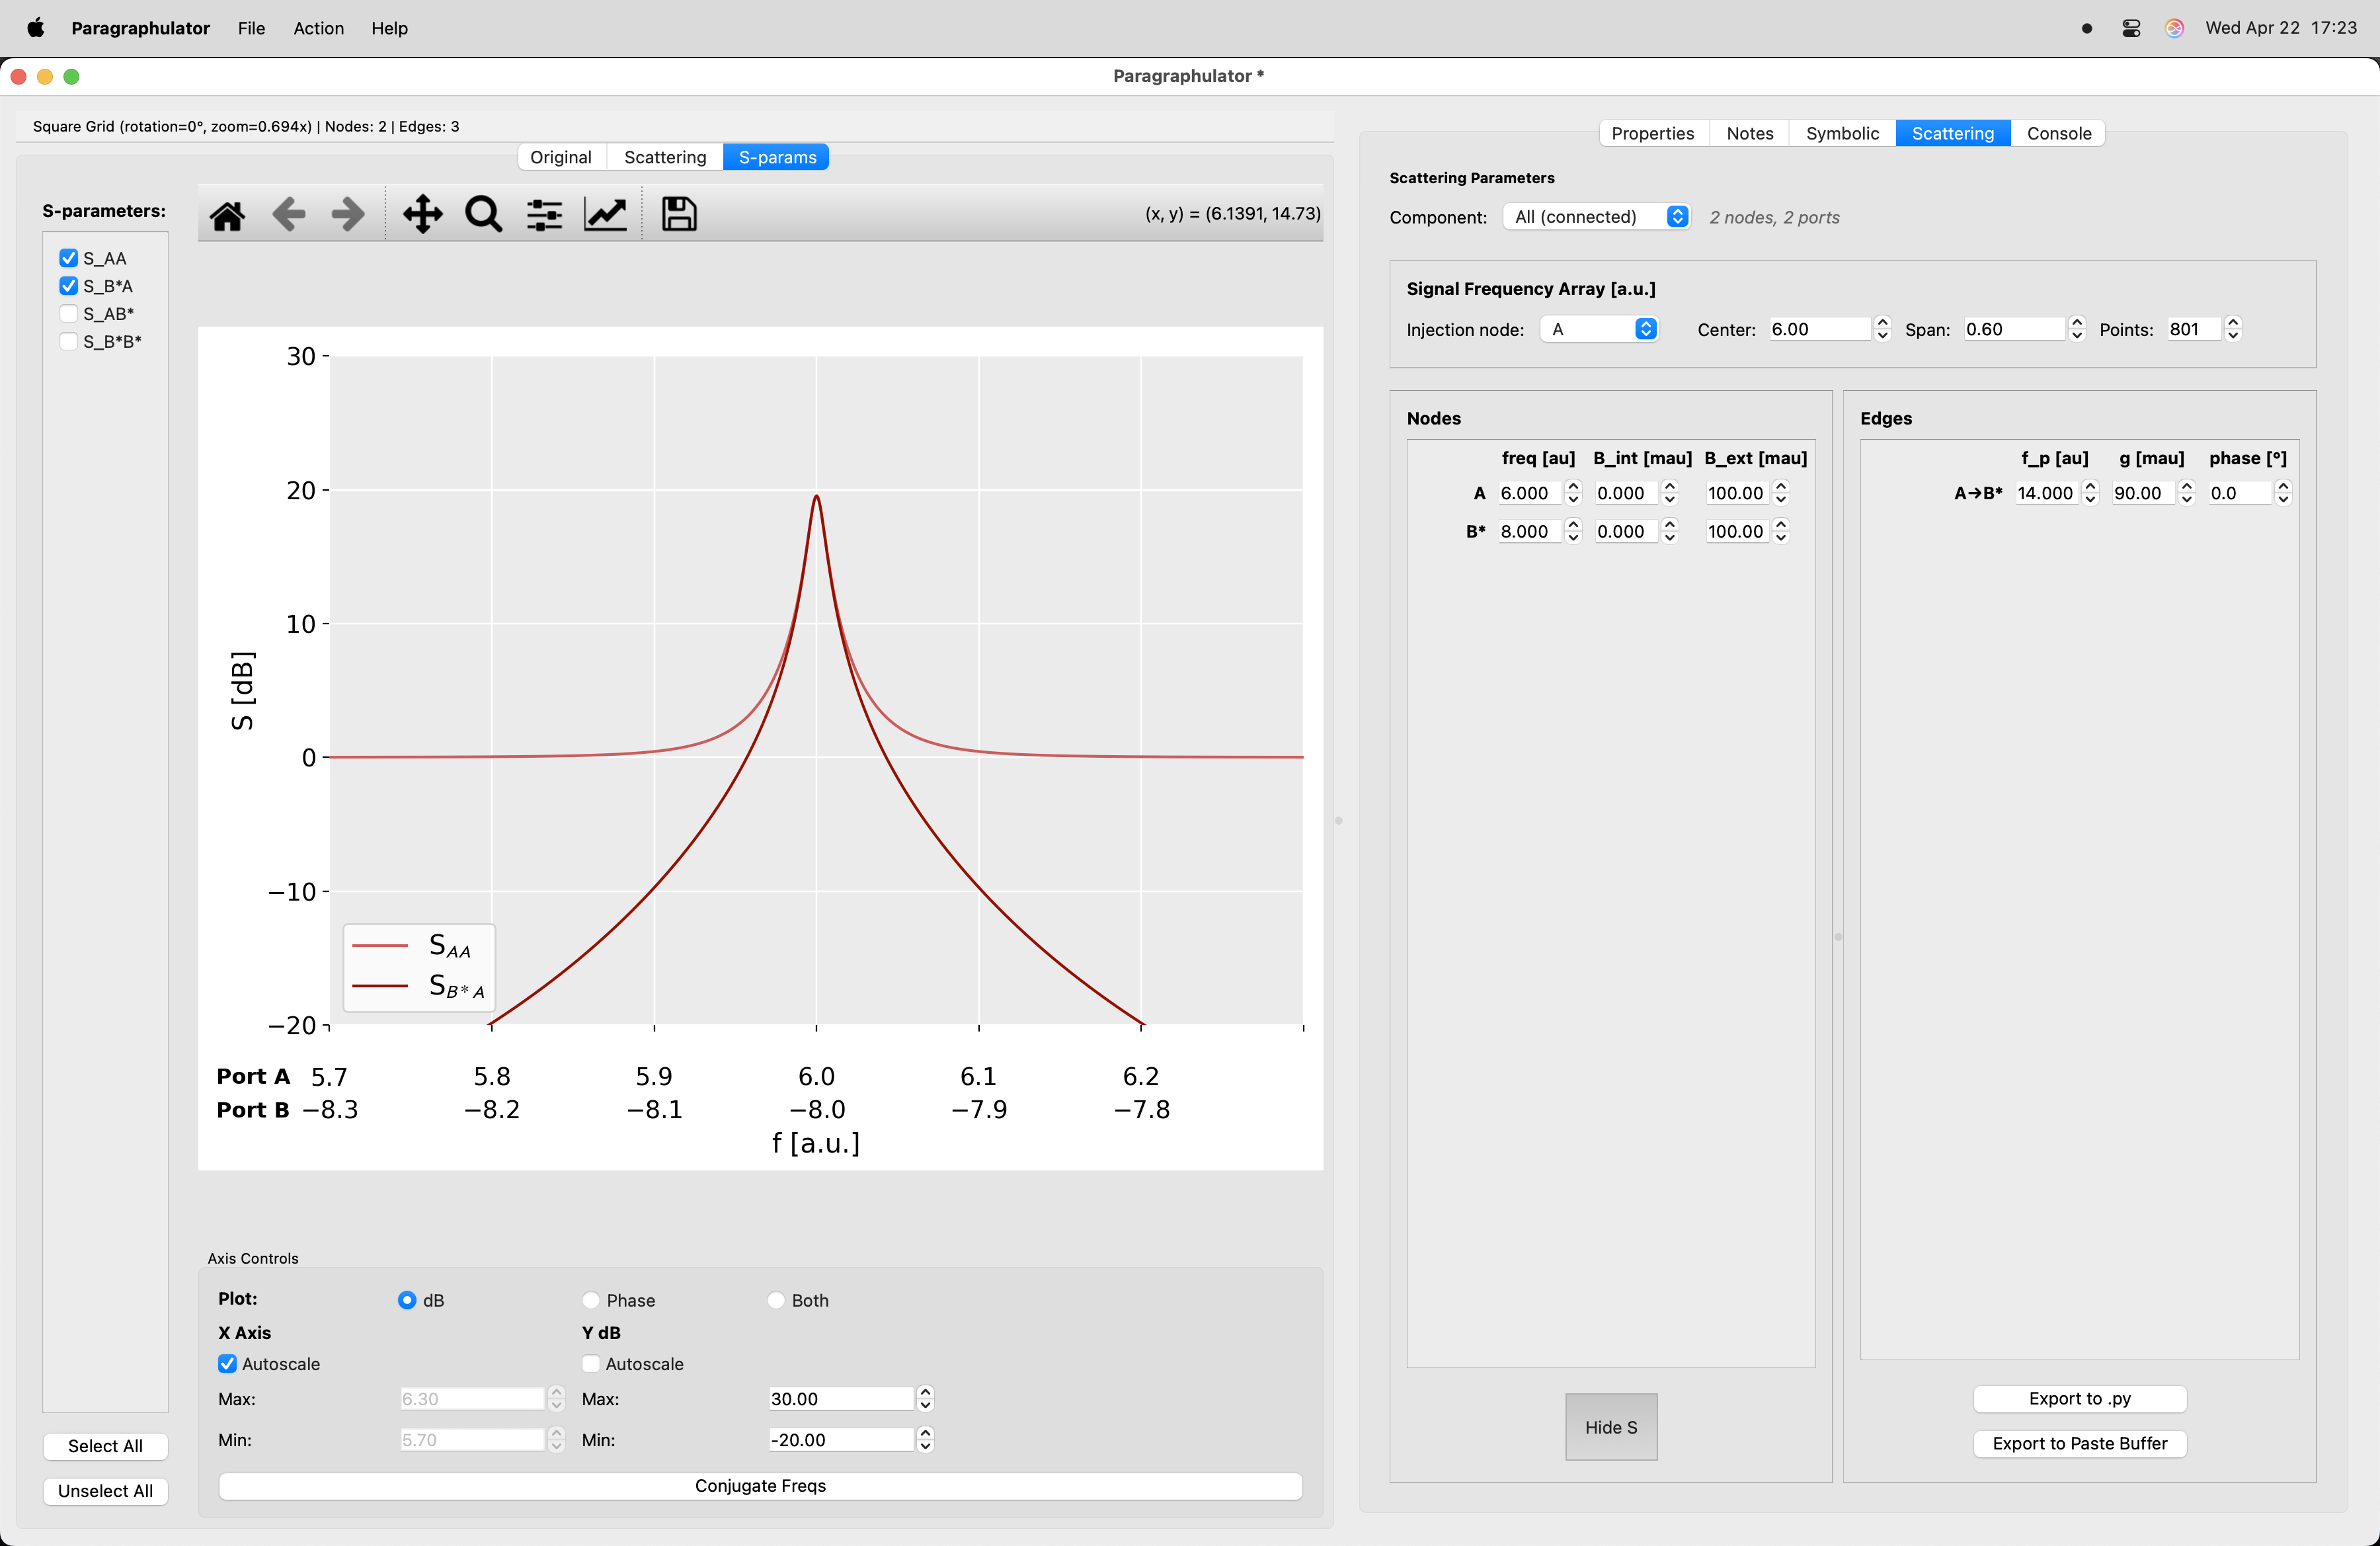

With any populated/defined graph you can click "Export to Paste Buffer" to copy the generated code which you can paste directly into Jupyter. As long as you have the `graphulator` package installed, the code should run without modification. You can then extend the code to plot the scattering parameters as a function of some parameter of interest, such as the coupling strength `g` in this case.

Computed S-matrix: 2 ports, 801 frequency points


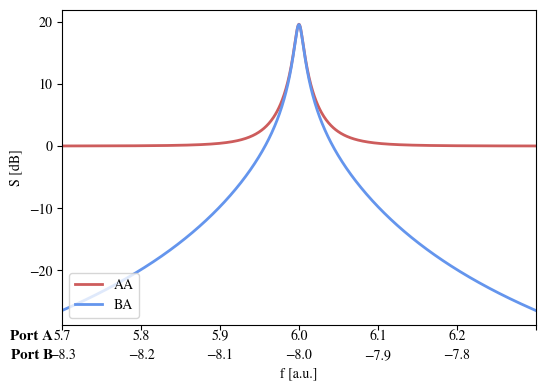

In [17]:
"""
Scattering calculation code exported from Graphulator
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from graphulator.autograph import GraphExtractor, GraphScatteringMatrix

# Set plot style (uncomment/modify to customize appearance)
# sns.set_theme(style='whitegrid', context='talk', font_scale=1.0)

# Graph structure
nodes = [
    {'node_id': 0, 'label': 'A', 'pos': [-4.0, 4.0], 'conj': False},
    {'node_id': 1, 'label': 'B', 'pos': [1.0, 4.0], 'conj': True}
]

edges = [
    {'from_node_id': 0, 'to_node_id': 1, 'is_self_loop': False},
    {'from_node_id': 0, 'to_node_id': 0, 'is_self_loop': True},
    {'from_node_id': 1, 'to_node_id': 1, 'is_self_loop': True}
]

# Scattering assignments keyed by object id
scattering_assignments = {
    id(nodes[0]): {'freq': 6.0, 'B_int': 0.0, 'B_ext': 0.1},  # node A,
    id(nodes[1]): {'freq': 8.0, 'B_int': 0.0, 'B_ext': 0.1},  # node B,
    id(edges[0]): {'f_p': 14.0, 'rate': 0.09, 'phase': 0.0},  # A→B*,
    id(edges[1]): {'f_p': None, 'rate': None, 'phase': 0.0},  # A→A,
    id(edges[2]): {'f_p': None, 'rate': None, 'phase': 0.0},  # B*→B*
}

# Frequency settings
frequency_settings = {
    'start': 5.7,
    'stop': 6.3,
    'points': 801
}

# Root node for spanning tree
root_node_id = 0

# Pre-computed spanning tree decomposition
tree_edges = [[0, 1]]
chord_edges = []

# Extract graph data
extractor = GraphExtractor()
graph_data = extractor.extract_graph_data(
    nodes=nodes,
    edges=edges,
    scattering_assignments=scattering_assignments,
    frequency_settings=frequency_settings,
    root_node_id=root_node_id,
    precomputed_tree_edges=tree_edges,
    precomputed_chord_edges=chord_edges
)

# Generate frequency array
f_center = 6.0
f_span = 0.6
frequencies = np.linspace(f_center - f_span/2, f_center + f_span/2, 801)

# Compute S-matrix
scattering_matrix = GraphScatteringMatrix(extractor, frequencies)

print(f"Computed S-matrix: {len(scattering_matrix.port_dict)} ports, {len(frequencies)} frequency points")

# ============================================================================
# Plot S-parameters
# ============================================================================
gsm = scattering_matrix
gsm.clear_traces()
gsm.add_trace(0, 0, color='indianred', linestyle='-', linewidth=2.0)  # S_AA
gsm.add_trace(1, 0, color='cornflowerblue', linestyle='-', linewidth=2.0)  # S_B*A

fig, ax = gsm.plot_SdB()
plt.show()


In this example, let's look at detuning and coupling rate dependence of the gain. We'll just wrap the meat of the generated code (the graph definition and the graph scattering object that does the calculation) in a function that takes `g` and `delta` as arguments, and then we'll call that function for a range of values to generate the plots below.

In [34]:
def calcSparameters(gMHz = 90, delta_fGHz = 0.0,
                    fGHz=6.0, f_span=0.6, points=801,
                    ):
    """
    Calculate S-parameters for a given coupling strength and detuning.
    
    Parameters:
    - gMHz: Coupling strength (rate) between nodes A and B in MHz
    - delta_fGHz: Detuning between the nodes (f_B - f_A) in GHz
    - delta_f: Detuning between the nodes (f_B - f_A)
    - fGHz: Center frequency in GHz
    - f_span: Frequency span around the center frequency in GHz
    - points: Number of frequency points to calculate
    
    Returns:
    - frequencies: Array of frequency points
    - S_AA_dB: S_AA parameter in dB
    - S_BA_dB: S_B*A parameter in dB
    """
    
    
    # Graph structure
    nodes = [
        {'node_id': 0, 'label': 'A', 'pos': [-4.0, 4.0], 'conj': False},
        {'node_id': 1, 'label': 'B', 'pos': [1.0, 4.0], 'conj': True}
    ]

    edges = [
        {'from_node_id': 0, 'to_node_id': 1, 'is_self_loop': False},
        {'from_node_id': 0, 'to_node_id': 0, 'is_self_loop': True},
        {'from_node_id': 1, 'to_node_id': 1, 'is_self_loop': True}
    ]

    # Scattering assignments keyed by object id
    scattering_assignments = {
        id(nodes[0]): {'freq': 6.0, 'B_int': 0.0, 'B_ext': 0.1},  # node A,
        id(nodes[1]): {'freq': 8.0, 'B_int': 0.0, 'B_ext': 0.1},  # node B,
        id(edges[0]): {'f_p': 14.0 + delta_fGHz, 'rate': gMHz * 1e-3, 'phase': 0.0},  # A→B*,   <---------- here's the  coupling & detuning
        id(edges[1]): {'f_p': None, 'rate': None, 'phase': 0.0},  # A→A,
        id(edges[2]): {'f_p': None, 'rate': None, 'phase': 0.0},  # B*→B*
    }

    # Frequency settings
    frequency_settings = {
        'start': fGHz - f_span / 2,
        'stop': fGHz + f_span / 2,
        'points': points
    }
    frequencies = np.linspace(frequency_settings['start'], frequency_settings['stop'], frequency_settings['points'])

    # Root node for spanning tree
    root_node_id = 0

    # Pre-computed spanning tree decomposition
    tree_edges = [[0, 1]]
    chord_edges = []

    # Extract graph data
    extractor = GraphExtractor()
    graph_data = extractor.extract_graph_data(
        nodes=nodes,
        edges=edges,
        scattering_assignments=scattering_assignments,
        frequency_settings=frequency_settings,
        root_node_id=root_node_id,
        precomputed_tree_edges=tree_edges,
        precomputed_chord_edges=chord_edges
    )



    # Compute S-matrix
    scattering_matrix = GraphScatteringMatrix(extractor, frequencies)


    # Extract S-parameters
    S_AA_dB = scattering_matrix.SdB[:, 0, 0]  # S_AA
    S_BA_dB = scattering_matrix.SdB[:, 1, 0]  # S_B*A

    return frequencies, S_AA_dB, S_BA_dB

# test
# freq, S_AA_dB, S_BA_dB = calcSparameters()

# plt.plot(freq, S_AA_dB, label='S_AA (dB)')


def imgSAA(gMHz = 90, delta_fGHzarr = np.linspace(-0.8,0.8,11),
           fGHz=6.0, f_span=0.6, points=801):

    SAA_dB_img = np.zeros((points, len(delta_fGHzarr)))

    for i, delta_fGHz in enumerate(delta_fGHzarr):
        freq, S_AA_dB, S_BA_dB = calcSparameters(gMHz, delta_fGHz)
        SAA_dB_img[:, i] = S_AA_dB

    plt.figure(figsize=(8, 6))
    extent = [freq[0], freq[-1], delta_fGHzarr[0], delta_fGHzarr[-1] ]
    plt.imshow(SAA_dB_img.T, aspect='auto', extent=extent, origin='lower', cmap='jet')
    plt.colorbar(label='$S_{AA}$ [dB]')
    plt.xlabel('Frequency [GHz]')
    plt.ylabel('Detuning Δf [GHz]')
    plt.title(f'$S_{{AA}}$ vs Frequency and Detuning (g={gMHz} MHz)')
    plt.show()

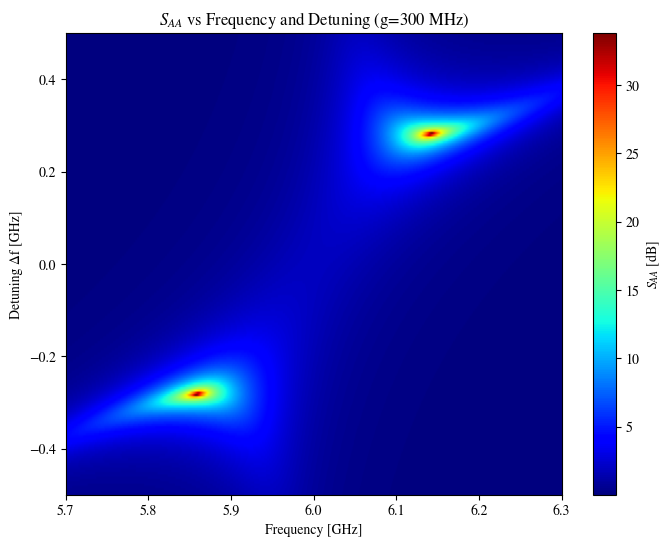

In [39]:
imgSAA(gMHz = 300, delta_fGHzarr=np.linspace(-0.5,0.5,201),
       f_span=1.0)